This script aims at reproducing the results from the paper "Out-Of-Distribution Detection Is Not All You Need".

```code
@misc{guérin2023outofdistributiondetectionneed,
      title={Out-Of-Distribution Detection Is Not All You Need}, 
      author={Joris Guérin and Kevin Delmas and Raul Sena Ferreira and Jérémie Guiochet},
      year={2023},
      eprint={2211.16158},
      archivePrefix={arXiv},
      primaryClass={cs.LG},
      url={https://arxiv.org/abs/2211.16158}, 
}
```


## Results Generation

### Load and run script V1

This version tries and reproduces the results seen in the paper comparing OOD and OMS paradigms.

In [106]:
%load Scripts/study_basic_monitors_script_v1.py

### Load and run script V2

This version adds new metrics (AUROC, AUPR, TNR@TPRx) to compare the monitors

In [135]:
# %load Scripts/study_basic_monitors_script_v2.py
"""
Script to generate results used in pairwise comparisons of monitors
with general metrics
"""

import csv
import os
import sys
import torch
from sklearn.metrics import accuracy_score

# ## Adjuste PATH variable to launch script from project root ##
# sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
# ## -------------------------------------------------------- ##

from dataset import Dataset
from feature_extractor import FeatureExtractor
from evaluator import Evaluator
from Monitors import (
    EnergyMonitor,
    MSPMonitor,
    OTBMonitor,
    ReActMonitor,
    MahalanobisMonitor,
)

import warnings
warnings.filterwarnings('ignore')


batch_size = 10
TORCH_DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

all_networks = ["resnet", "densenet"]
all_networks_layers = [[0, 32], 
                       [0, 98]]
all_datasets = ["cifar10", "svhn", "cifar100"]
all_datasets_ood = [["cifar100", "svhn", "lsun"],
                    ["cifar10", "tiny_imagenet", "lsun"],
                    ["cifar10", "svhn", "lsun"]]
all_perturbations = ["brightness", "blur", "pixelization"]
all_adver_attacks = ["fgsm", "deepfool", "pgd"]

path_to_save_results = "Results/OOD_vs_OMS/"
path_to_results_file = path_to_save_results + "full_results_v2_metrics.csv"
if not os.path.exists(path_to_save_results):
    os.makedirs(path_to_save_results)

f = open(path_to_results_file, "w", newline='', encoding="UTF8")
writer = csv.writer(f)
header = [
    "Network", "Network Layer",
    "Dataset ID", "Dataset OOD", "Perturbation", "Attack",
    "Accuracy ID", "Accuracy OOD",
    "Precision OMS@OOD*", "Recall OMS@OOD*", "F1 OMS@OOD*",
    "Monitor",
    "Precision [OOD]", "Recall [OOD]", "F1 [OOD]", 
    "AUROC [OOD]", "AUPR [OOD]", "TNR95TPR [OOD]",
    "Precision [OMS]", "Recall [OMS]", "F1 [OMS]", 
    "AUROC [OMS]", "AUPR [OMS]", "TNR95TPR [OMS]",
]
writer.writerow(header)
f.close()


def evaluate_monitors(
        file_to_save_results,
        network,
        network_layers,
        dataset_ID,
        dataset_OOD,
        perturbation=None,
        adver_attack=None,
):
    f = open(file_to_save_results, "a", newline='', encoding="UTF8")
    writer = csv.writer(f)
    
    dataset_train = Dataset(dataset_ID, "train", network, batch_size=batch_size)
    dataset_test = Dataset(dataset_ID, "test", network, batch_size=batch_size)
    dataset_ood = Dataset(dataset_OOD, "test", network, perturbation, adver_attack, batch_size=batch_size)

    feature_extractor = FeatureExtractor(network, dataset_ID, network_layers, TORCH_DEVICE)

    deep_features_train = feature_extractor.get_features(dataset_train)
    deep_features_test = feature_extractor.get_features(dataset_test)
    deep_features_ood = feature_extractor.get_features(dataset_ood)

    features_train, logits_train, softmax_train, \
        pred_train, lab_train = deep_features_train
    features_test, logits_test, softmax_test, \
        pred_test, lab_test = deep_features_test
    features_ood, logits_ood, softmax_ood, \
        pred_ood, lab_ood = deep_features_ood

    accuracy_id = accuracy_score(lab_test, pred_test)
    accuracy_ood = 0
    if dataset_ID == dataset_OOD:
        accuracy_ood = accuracy_score(lab_ood, pred_ood) 

    eval_oms = Evaluator("oms", is_novelty=(dataset_ID!=dataset_OOD))
    eval_ood = Evaluator("ood", is_novelty=(dataset_ID!=dataset_OOD))
    eval_oms.fit_ground_truth(lab_test, lab_ood, pred_test, pred_ood)
    eval_ood.fit_ground_truth(lab_test, lab_ood, pred_test, pred_ood)

    prec_star, recall_star, f1_star = eval_oms.get_metrics_at_f1_opt(
        eval_ood.y_true[:lab_test.shape[0]].astype(bool),
        eval_ood.y_true[lab_test.shape[0]:].astype(bool) 
    )

    # # Evaluate MSP
    # metrics = _evaluate_MSP(
    #     deep_features_train,
    #     deep_features_test,
    #     deep_features_ood,
    #     eval_oms, eval_ood,
    #     monitor_args=[],
    #     monitor_kwargs={})
    # results = [network, 1,
    #     dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
    #     accuracy_id, accuracy_ood,
    #     prec_star, recall_star, f1_star,
    #     "MSP",
    #     metrics[0], metrics[1], metrics[2],
    #     metrics[3], metrics[4], metrics[5]]
    # writer.writerow(results)

    # Evaluate MSP
    monitor = MSPMonitor()
    monitor.fit()

    scores_test = monitor.predict(softmax_test)
    scores_ood  = monitor.predict(softmax_ood)

    prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
    prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

    auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
    auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
    aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
    aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
    tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
    tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

    result = [
        network, 1,
        dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
        accuracy_id, accuracy_ood,
        prec_star, recall_star, f1_star,
        "MSP",
        prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood, 
        prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
    writer.writerow(result)
    
    # Evaluate Ene
    monitor = EnergyMonitor(T=1)
    monitor.fit()

    scores_test = monitor.predict(logits_test)
    scores_ood  = monitor.predict(logits_ood)

    prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
    prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

    auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
    auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
    aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
    aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
    tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
    tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

    result = [
        network, 1,
        dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
        accuracy_id, accuracy_ood,
        prec_star, recall_star, f1_star,
        "Ene",
        prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood,
        prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
    writer.writerow(result)

    # Evaluate Re-MSP
    monitor = ReActMonitor(quantile_value=0.99, mode="MSP")
    monitor.fit(feature_extractor, features_train[-1])

    scores_test = monitor.predict(features_test[-1])
    scores_ood  = monitor.predict(features_ood[-1])

    prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
    prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

    auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
    auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
    aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
    aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
    tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
    tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

    result = [
        network, 1,
        dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
        accuracy_id, accuracy_ood,
        prec_star, recall_star, f1_star,
        "Re-MSP",
        prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood,
        prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
    writer.writerow(result)

    # Evaluate Re-Ene
    monitor = ReActMonitor(quantile_value=0.99, mode="energy")
    monitor.fit(feature_extractor, features_train[-1])

    scores_test = monitor.predict(features_test[-1])
    scores_ood  = monitor.predict(features_ood[-1])

    prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
    prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

    auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
    auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
    aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
    aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
    tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
    tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

    result = [
        network, 1,
        dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
        accuracy_id, accuracy_ood,
        prec_star, recall_star, f1_star,
        "Re-Ene",
        prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood,
        prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
    writer.writerow(result)

    # Evaluate OTB
    for i_layer in range(len(network_layers)):
        monitor = OTBMonitor(dataset_ID, network, i_layer, n_clusters=10)
        monitor.fit(features_train[i_layer], pred_train, lab_train, save=False)

        scores_test = monitor.predict(features_test[i_layer], pred_test)
        scores_ood  = monitor.predict(features_ood[i_layer], pred_ood)

        prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
        prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

        auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
        auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
        aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
        aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
        tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
        tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

        result = [
            network, i_layer,
            dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
            accuracy_id, accuracy_ood,
            prec_star, recall_star, f1_star,
            "OTB",
            prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood,
            prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
        writer.writerow(result)

    # Evaluate Maha
    for i_layer in range(len(network_layers)):
        monitor = MahalanobisMonitor(dataset_ID, network, i_layer, is_tied=True)
        monitor.fit(features_train[i_layer], pred_train, lab_train, save=False)

        scores_test = monitor.predict(features_test[i_layer], pred_test)
        scores_ood  = monitor.predict(features_ood[i_layer], pred_ood)

        prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
        prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)

        auroc_ood = eval_ood.get_auroc_score(scores_test, scores_ood)
        auroc_oms = eval_oms.get_auroc_score(scores_test, scores_ood)
        aupr_ood = eval_ood.get_aupr_score(scores_test, scores_ood)
        aupr_oms = eval_oms.get_aupr_score(scores_test, scores_ood)
        tnr95tpr_ood = eval_ood.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)
        tnr95tpr_oms = eval_oms.get_tnr_frac_tpr(scores_test, scores_ood, frac=.95)

        result = [
            network, i_layer,
            dataset_ID, dataset_OOD, str(perturbation), str(adver_attack),
            accuracy_id, accuracy_ood,
            prec_star, recall_star, f1_star,
            "Maha",
            prec_ood, recall_ood, f1_ood, auroc_ood, aupr_ood, tnr95tpr_ood,
            prec_oms, recall_oms, f1_oms, auroc_oms, aupr_oms, tnr95tpr_oms]
        writer.writerow(result)
    
    f.close()


# def _evaluate_MSP(
#         deep_features_train,
#         deep_features_test,
#         deep_features_ood,
#         eval_oms=None, 
#         eval_ood=None,
#         monitor_args=[],
#         monitor_kwargs={}
# ):
#     monitor = MSPMonitor()
#     monitor.fit()

#     scores_test = monitor.predict(deep_features_test[2])
#     scores_ood  = monitor.predict(deep_features_ood[2])

#     prec_oms, recall_oms, f1_oms = eval_oms.get_metrics_at_f1_opt(scores_test, scores_ood)
#     prec_ood, recall_ood, f1_ood = eval_ood.get_metrics_at_f1_opt(scores_test, scores_ood)
    
#     return (prec_ood, recall_ood, f1_ood,
#             prec_oms, recall_oms, f1_oms)


for i_network in range(len(all_networks)):
    network = all_networks[i_network]
    network_layers = all_networks_layers[i_network]

    for i_dataset in range(len(all_datasets)):
        dataset = all_datasets[i_dataset]
        
        # Test with OOD as novelty
        for j_dataset in range(len(all_datasets_ood)):
            dataset_ood = all_datasets_ood[i_dataset][j_dataset]

            print("=== Monitoring %s, for dataset %s and OOD dataset %s." % (network, dataset, (dataset_ood, None, None)), flush=True)
            evaluate_monitors(
                path_to_results_file,
                network, network_layers,
                dataset, dataset_ood
            )

        # Test with OOD as cov shift
        for j in range(len(all_perturbations)):
            dataset_ood = dataset
            perturbation = all_perturbations[j]

            print("=== Monitoring %s, for dataset %s and OOD dataset %s." % (network, dataset, (dataset_ood, perturbation, None)), flush=True)
            evaluate_monitors(
                path_to_results_file,
                network, network_layers,
                dataset, dataset_ood,
                perturbation=perturbation
            )

        # Test with OOD as adversarial attack
        for j in range(len(all_adver_attacks)):
            dataset_ood = dataset
            adver_attack = all_adver_attacks[j]

            print("=== Monitoring %s, for dataset %s and OOD dataset %s." % (network, dataset, (dataset_ood, None, adver_attack)), flush=True)
            evaluate_monitors(
                path_to_results_file,
                network, network_layers,
                dataset, dataset_ood,
                adver_attack=adver_attack
            )


=== Monitoring resnet, for dataset cifar10 and OOD dataset ('cifar100', None, None).
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


## Results Analysis -- v1

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

In [115]:
df = pd.read_csv("./Results/OOD_vs_OMS/full_results_v1.csv")

In [116]:
def choose_OOD(t):
    if t[0].lower() != t[1].lower():
        return "1_" + t[1]
    if str(t[2]).lower() != "nan":
        return "2_" + t[2]
    if str(t[3]).lower() != "nan":
        return "3_" + t[3]
    raise ValueError("Too bad")

df["Dataset OOD"] = df.apply(lambda x: choose_OOD([x['Dataset'],x['Dataset OOD'],x['Perturbation'],x['Attack']]),axis=1,)
df["OOD type"] = df["Dataset OOD"].apply(lambda x: int(x[0]))

df = df.rename(columns={"Dataset": "Dataset ID"})
df = df.drop(columns=["Perturbation", "Attack"])
df

,Network,Network Layer,Dataset ID,Dataset OOD,Accuracy ID,Accuracy OOD,Precision OMS@OOD*,Recall OMS@OOD*,F1 OMS@OOD*,Monitor,Precision OOD,Recall OOD,F1 OOD,Precision OMS,Recall OMS,F1 OMS,OOD type
0,resnet,1,cifar10,1_cifar100,0.9367,0.0000,1.0000,0.940468,0.969321,MSP,0.500000,1.0000,0.666667,0.531650,1.000000,0.694219,1
1,resnet,1,cifar10,1_cifar100,0.9367,0.0000,1.0000,0.940468,0.969321,Ene,0.500000,1.0000,0.666667,0.531650,1.000000,0.694219,1
2,resnet,1,cifar10,1_cifar100,0.9367,0.0000,1.0000,0.940468,0.969321,Re-MSP,0.500000,1.0000,0.666667,0.531650,1.000000,0.694219,1
3,resnet,1,cifar10,1_cifar100,0.9367,0.0000,1.0000,0.940468,0.969321,Re-Ene,0.500000,1.0000,0.666667,0.531650,1.000000,0.694219,1
4,resnet,0,cifar10,1_cifar100,0.9367,0.0000,1.0000,0.940468,0.969321,OTB,0.500000,1.0000,0.666667,0.531650,1.000000,0.694219,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,densenet,1,cifar100,3_pgd,0.7762,0.0193,0.9807,0.814197,0.889726,Re-Ene,0.500000,1.0000,0.666667,0.602250,1.000000,0.751755,3
428,densenet,0,cifar100,3_pgd,0.7762,0.0193,0.9807,0.814197,0.889726,OTB,0.543294,0.9443,0.689748,0.617888,0.971025,0.755214,3
429,densenet,1,cifar100,3_pgd,0.7762,0.0193,0.9807,0.814197,0.889726,OTB,0.500000,1.0000,0.666667,0.602250,1.000000,0.751755,3
430,densenet,0,cifar100,3_pgd,0.7762,0.0193,0.9807,0.814197,0.889726,Maha,0.500426,0.9995,0.666934,0.602472,0.999668,0.751834,3


### OMS at OOD*

Extract results under OMS paradigm for optimal OOD detector

In [71]:
# df_OMS_at_OODstar = df.groupby(['Dataset ID', 'Dataset OOD'])
# df_OMS_at_OODstar_PR = df_OMS_at_OODstar[['Precision OMS@OOD*', 'Recall OMS@OOD*']].agg("mean")
# df_OMS_at_OODstar_PR

df_OMS_at_OODstar_PR_stats = df.groupby(['OOD type'])[['Precision OMS@OOD*', 'Recall OMS@OOD*']].agg(['mean', 'std'])
df_OMS_at_OODstar_PR_stats

Precision OMS@OOD*           Recall OMS@OOD*          
                       mean       std            mean       std
OOD type                                                       
1                  1.000000  0.000000        0.909548  0.052213
2                  0.546569  0.303161        0.813128  0.120102
3                  0.714344  0.200742        0.884986  0.066096

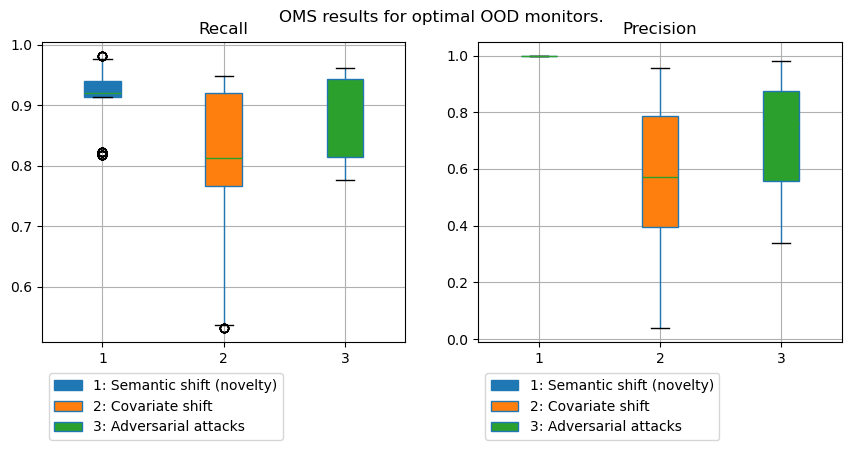

In [72]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))
labels = ['Semantic shift (novelty)',
          'Covariate shift',
          'Adversarial attacks']
colors = ['tab:blue', 'tab:orange', 'tab:green']
column = ['Recall OMS@OOD*', 'Precision OMS@OOD*']

for i in range(len(axs)):
    ax = axs[i]
    bp = df.boxplot(
        ax=ax,
        by='OOD type',
        column=column[i],
        return_type='dict',
        patch_artist=True,
    )
    ax.set_title(column[i].split()[0])
    ax.set_xlabel('')
    for j,box in enumerate(bp.iloc[0]['boxes']):
        box.set_facecolor(colors[j])
    ax.legend([bp.iloc[0]['boxes'][j] for j in range(len(colors))], 
              [f"{i+1}: {j}" for i, j in enumerate(labels)],
              loc="lower left", bbox_to_anchor=(0.,-.35))

plt.suptitle('OMS results for optimal OOD monitors.')
plt.show()

### Pairwise comparisons on P, R

In [73]:
from scipy.stats import wilcoxon

In [74]:
def compute_average_ranking(lst1, lst2, pct=True):
    # Create a DataFrame with the combined data and indicator column
    data = pd.DataFrame({'Value': lst1+lst2, 
                         'Group': ['list 1']*len(lst1) + ['list 2']*len(lst2)})

    # Compute the average ranks using pandas functions
    avg_rank = data.Value.rank(pct=pct).groupby(data.Group).mean()

    # Groupby the original lists and compute the mean average ranks
    avg_ranks_lst1 = avg_rank.iloc[0]
    avg_ranks_lst2 = avg_rank.iloc[1]

    return avg_ranks_lst1, avg_ranks_lst2

In [75]:
alpha = 0.05

monitors = ['OTB', 'Maha', 'MSP', 'Ene', 'Re-MSP', 'Re-Ene']

#### Under de OOD paradigm

In [98]:
df_OOD_wilcoxon = df.groupby(['Network Layer', 'Monitor'])
df_OOD_P = df_OOD_wilcoxon['Precision OOD'].agg(lambda x: list(x))
df_OOD_R = df_OOD_wilcoxon['Recall OOD'].agg(lambda x: list(x))
df_OOD_F1 = df_OOD_wilcoxon['F1 OOD'].agg(lambda x: list(x))

wilcoxon_mat_OOD_P = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OOD_R = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OOD_P_flag = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OOD_R_flag = np.zeros((len(monitors)-1, len(monitors)-1))

for j in range(1, len(monitors)):
    for i in range(0, j):
        monitor_i = monitors[i]  # row monitor
        monitor_j = monitors[j]  # col monitor

        wilcoxon_stats_P, wilcoxon_pvalue_P = wilcoxon(df_OOD_P[(1,monitor_i)], df_OOD_P[(1, monitor_j)], alternative="two-sided")
        wilcoxon_stats_R, wilcoxon_pvalue_R = wilcoxon(df_OOD_R[(1,monitor_i)], df_OOD_R[(1, monitor_j)], alternative="two-sided")
        
        wilcoxon_mat_OOD_P[i,j-1] = wilcoxon_pvalue_P
        wilcoxon_mat_OOD_R[i,j-1] = wilcoxon_pvalue_R

        if wilcoxon_pvalue_P <= alpha:
            avg_rnk_i_P, avg_rnk_j_P = compute_average_ranking(df_OOD_P[(1,monitor_i)], df_OOD_P[(1, monitor_j)])

            if avg_rnk_i_P <= avg_rnk_j_P:
                wilcoxon_mat_OOD_P_flag[i,j-1] = +1
            else:
                wilcoxon_mat_OOD_P_flag[i,j-1] = -1
        else:
            wilcoxon_mat_OOD_P_flag[i,j-1] = 0

        if wilcoxon_pvalue_R <= alpha:
            avg_rnk_i_R, avg_rnk_j_R = compute_average_ranking(df_OOD_R[(1,monitor_i)], df_OOD_R[(1, monitor_j)])

            if avg_rnk_i_R <= avg_rnk_j_R:
                wilcoxon_mat_OOD_R_flag[i,j-1] = +1
            else:
                wilcoxon_mat_OOD_R_flag[i,j-1] = -1
        else:
            wilcoxon_mat_OOD_R_flag[i,j-1] = 0


# print(wilcoxon_mat_OOD_P_flag)
# print(wilcoxon_mat_OOD_R_flag)

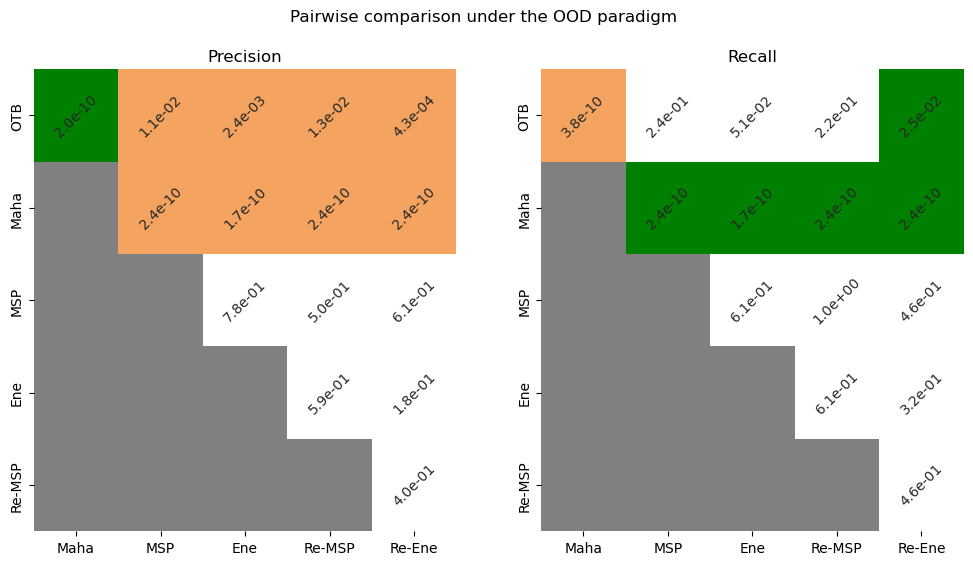

In [97]:
figlen = 6
nrow = 1
ncol = 2
fig, axs = plt.subplots(nrow, ncol, figsize=(ncol*figlen,nrow*figlen))

# Plot the P results
plot_P = sns.heatmap(wilcoxon_mat_OOD_P, annot=True, fmt='.1e', cbar=False, annot_kws={'rotation': 45},
                   mask=(np.tril(np.ones_like(wilcoxon_mat_OOD_P),k=-1)),
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['White']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OOD_P, mask=(wilcoxon_mat_OOD_P_flag!=+1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Green']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OOD_P, mask=(wilcoxon_mat_OOD_P_flag!=-1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Sandybrown']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OOD_P, mask=(np.triu(np.ones_like(wilcoxon_mat_OOD_P))), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Grey']), ax=axs[0])
axs[0].set_title('Precision')

# Plot the R results
plot_R = sns.heatmap(wilcoxon_mat_OOD_R, annot=True, fmt='.1e', cbar=False, annot_kws={'rotation': 45},
                   mask=(np.tril(np.ones_like(wilcoxon_mat_OOD_R),k=-1)),
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['White']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OOD_R, mask=(wilcoxon_mat_OOD_R_flag!=+1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Green']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OOD_R, mask=(wilcoxon_mat_OOD_R_flag!=-1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Sandybrown']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OOD_R, mask=(np.triu(np.ones_like(wilcoxon_mat_OOD_R))), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Grey']), ax=axs[1])
axs[1].set_title('Recall')

plt.suptitle("Pairwise comparison under the OOD paradigm")
plt.show()

#### Under the OMS paradigm

In [103]:
df_OMS_wilcoxon = df.groupby(['Network Layer', 'Monitor'])
df_OMS_P = df_OMS_wilcoxon['Precision OMS'].agg(lambda x: list(x))
df_OMS_R = df_OMS_wilcoxon['Recall OMS'].agg(lambda x: list(x))
df_OMS_F1 = df_OMS_wilcoxon['F1 OMS'].agg(lambda x: list(x))

wilcoxon_mat_OMS_P = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OMS_R = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OMS_P_flag = np.zeros((len(monitors)-1, len(monitors)-1))
wilcoxon_mat_OMS_R_flag = np.zeros((len(monitors)-1, len(monitors)-1))

for j in range(1, len(monitors)):
    for i in range(0, j):
        monitor_i = monitors[i]  # row monitor
        monitor_j = monitors[j]  # col monitor

        try:
            wilcoxon_stats_P, wilcoxon_pvalue_P = wilcoxon(df_OMS_P[(1,monitor_i)], df_OMS_P[(1, monitor_j)], alternative="two-sided")
            if wilcoxon_pvalue_P <= alpha:
                avg_rnk_i_P, avg_rnk_j_P = compute_average_ranking(df_OMS_P[(1,monitor_i)], df_OMS_P[(1, monitor_j)])
                if avg_rnk_i_P <= avg_rnk_j_P:
                    wilcoxon_mat_OMS_P_flag[i,j-1] = +1
                else:
                    wilcoxon_mat_OMS_P_flag[i,j-1] = -1
            else:
                wilcoxon_mat_OMS_P_flag[i,j-1] = 0
            wilcoxon_mat_OMS_P[i,j-1] = wilcoxon_pvalue_P
        except ValueError as err:
            wilcoxon_mat_OMS_P[i,j-1] = 0
            wilcoxon_mat_OMS_P_flag[i,j-1] = 0

        try:
            wilcoxon_stats_R, wilcoxon_pvalue_R = wilcoxon(df_OMS_R[(1,monitor_i)], df_OMS_R[(1, monitor_j)], alternative="two-sided")
            if wilcoxon_pvalue_R <= alpha:
                avg_rnk_i_R, avg_rnk_j_R = compute_average_ranking(df_OMS_R[(1,monitor_i)], df_OMS_R[(1, monitor_j)])
                if avg_rnk_i_R <= avg_rnk_j_R:
                    wilcoxon_mat_OMS_R_flag[i,j-1] = +1
                else:
                    wilcoxon_mat_OMS_R_flag[i,j-1] = -1
            else:
                wilcoxon_mat_OMS_R_flag[i,j-1] = 0
            wilcoxon_mat_OMS_R[i,j-1] = wilcoxon_pvalue_R
        except ValueError as err:
            wilcoxon_mat_OMS_R[i,j-1] = 0
            wilcoxon_mat_OMS_R_flag[i,j-1] = 0

# print(wilcoxon_mat_OMS_P_flag)
# print(wilcoxon_mat_OMS_R_flag)

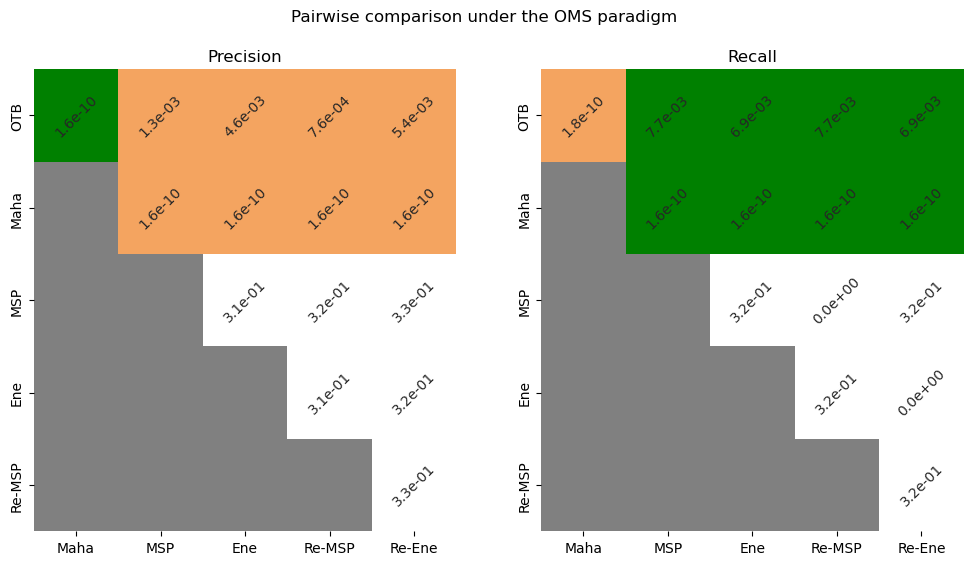

In [104]:
figlen = 6
nrow = 1
ncol = 2
fig, axs = plt.subplots(nrow, ncol, figsize=(ncol*figlen,nrow*figlen))

# Plot the P results
plot_P = sns.heatmap(wilcoxon_mat_OMS_P, annot=True, fmt='.1e', cbar=False, annot_kws={'rotation': 45},
                   mask=(np.tril(np.ones_like(wilcoxon_mat_OMS_P),k=-1)),
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['White']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OMS_P, mask=(wilcoxon_mat_OMS_P_flag!=+1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Green']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OMS_P, mask=(wilcoxon_mat_OMS_P_flag!=-1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Sandybrown']), ax=axs[0])
plot_P = sns.heatmap(wilcoxon_mat_OMS_P, mask=(np.triu(np.ones_like(wilcoxon_mat_OMS_P))), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Grey']), ax=axs[0])
axs[0].set_title('Precision')

# Plot the R results
plot_R = sns.heatmap(wilcoxon_mat_OMS_R, annot=True, fmt='.1e', cbar=False, annot_kws={'rotation': 45},
                   mask=(np.tril(np.ones_like(wilcoxon_mat_OMS_R),k=-1)),
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['White']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OMS_R, mask=(wilcoxon_mat_OMS_R_flag!=+1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Green']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OMS_R, mask=(wilcoxon_mat_OMS_R_flag!=-1), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Sandybrown']), ax=axs[1])
plot_R = sns.heatmap(wilcoxon_mat_OMS_R, mask=(np.triu(np.ones_like(wilcoxon_mat_OMS_R))), cbar=False, annot_kws={'rotation': 45},
                   xticklabels=monitors[1:],
                   yticklabels=monitors[:-1],
                   cmap=mcolors.ListedColormap(['Grey']), ax=axs[1])
axs[1].set_title('Recall')

plt.suptitle("Pairwise comparison under the OMS paradigm")
plt.show()

### MISC

In [124]:
df[(df['Monitor'] == 'Maha')&(df['Network'] == 'resnet')&(df['Network Layer'] == 1)&(df['Dataset ID'] == 'cifar100')]

,Network,Network Layer,Dataset ID,Dataset OOD,Accuracy ID,Accuracy OOD,Precision OMS@OOD*,Recall OMS@OOD*,F1 OMS@OOD*,Monitor,Precision OOD,Recall OOD,F1 OOD,Precision OMS,Recall OMS,F1 OMS,OOD type
151,resnet,1,cifar100,1_cifar10,0.7833,0.0000,1.0000,0.821895,0.902242,Maha,0.609345,0.849000,0.709481,0.716042,0.899893,0.797509,1
159,resnet,1,cifar100,1_svhn,0.7833,0.0000,1.0000,0.923153,0.960041,Maha,0.870606,0.962777,0.914374,0.902714,0.973013,0.936546,1
167,resnet,1,cifar100,1_lsun,0.7833,0.0000,1.0000,0.821895,0.902242,Maha,0.658942,0.904200,0.762330,0.768994,0.922577,0.838813,1
175,resnet,1,cifar100,2_brightness,0.7833,0.2679,0.7321,0.771606,0.751334,Maha,0.715071,0.871600,0.785614,0.693139,0.872049,0.772369,2
183,resnet,1,cifar100,2_blur,0.7833,0.0430,0.9570,0.815370,0.880526,Maha,0.816425,0.912600,0.861838,0.847516,0.896907,0.871513,2
191,resnet,1,cifar100,2_pixelization,0.7833,0.2897,0.7103,0.766235,0.737208,Maha,0.658407,0.892800,0.757895,0.648208,0.891478,0.750624,2
199,resnet,1,cifar100,3_fgsm,0.7833,0.2511,0.7489,0.775580,0.762007,Maha,0.654743,0.878600,0.750331,0.681306,0.890017,0.771801,3
207,resnet,1,cifar100,3_deepfool,0.7833,0.1252,0.8748,0.801466,0.836529,Maha,0.656857,0.892800,0.756867,0.706877,0.892808,0.789037,3
215,resnet,1,cifar100,3_pgd,0.7833,0.0510,0.9490,0.814103,0.876391,Maha,0.655443,0.901300,0.758958,0.760421,0.917046,0.831421,3


## Results -- v2

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
df = pd.read_csv("./Results/OOD_vs_OMS/full_results_v2_metrics.csv")

def choose_OOD(t):
    if t[0].lower() != t[1].lower():
        return "1_" + t[1]
    if str(t[2]).lower() != "nan":
        return "2_" + t[2]
    if str(t[3]).lower() != "nan":
        return "3_" + t[3]
    raise ValueError("Too bad")

df["Dataset OOD"] = df.apply(lambda x: choose_OOD([x['Dataset ID'],x['Dataset OOD'],x['Perturbation'],x['Attack']]),axis=1,)
df["OOD type"] = df["Dataset OOD"].apply(lambda x: int(x[0]))

df = df.drop(columns=["Perturbation", "Attack"])
df

In [133]:
df[(df['Monitor'] == 'Maha')&(df['Network'] == 'resnet')&(df['Network Layer'] == 1)&(df['Dataset ID'] == 'cifar100')]

,Network,Network Layer,Dataset ID,Dataset OOD,Accuracy ID,Accuracy OOD,Precision OMS@OOD*,Recall OMS@OOD*,F1 OMS@OOD*,Monitor,...,AUROC [OOD],AUPR [OOD],TNR95TPR [OOD],Precision [OMS],Recall [OMS],F1 [OMS],AUROC [OMS],AUPR [OMS],TNR95TPR [OMS],OOD type
151,resnet,1,cifar100,1_cifar10,0.7833,0.0000,1.0000,0.821895,0.902242,Maha,...,0.276136,0.368724,0.0142,0.716042,0.899893,0.797509,0.218759,0.448094,0.008937,1
159,resnet,1,cifar100,1_svhn,0.7833,0.0000,1.0000,0.923153,0.960041,Maha,...,0.107167,0.529555,0.0035,0.902714,0.973013,0.936546,0.082988,0.592871,0.001404,1
167,resnet,1,cifar100,1_lsun,0.7833,0.0000,1.0000,0.821895,0.902242,Maha,...,0.209128,0.344754,0.0140,0.768994,0.922577,0.838813,0.164489,0.428813,0.008554,1
175,resnet,1,cifar100,2_brightness,0.7833,0.2679,0.7321,0.771606,0.751334,Maha,...,0.156193,0.331050,0.0036,0.693139,0.872049,0.772369,0.161049,0.311636,0.016743,2
183,resnet,1,cifar100,2_blur,0.7833,0.0430,0.9570,0.815370,0.880526,Maha,...,0.077364,0.316704,0.0021,0.847516,0.896907,0.871513,0.092925,0.391782,0.004357,2
191,resnet,1,cifar100,2_pixelization,0.7833,0.2897,0.7103,0.766235,0.737208,Maha,...,0.192527,0.340159,0.0054,0.648208,0.891478,0.750624,0.181125,0.307498,0.020224,2
199,resnet,1,cifar100,3_fgsm,0.7833,0.2511,0.7489,0.775580,0.762007,Maha,...,0.214421,0.346325,0.0097,0.681306,0.890017,0.771801,0.173134,0.321389,0.018948,3
207,resnet,1,cifar100,3_deepfool,0.7833,0.1252,0.8748,0.801466,0.836529,Maha,...,0.210363,0.344948,0.0105,0.706877,0.892808,0.789037,0.197093,0.380775,0.013319,3
215,resnet,1,cifar100,3_pgd,0.7833,0.0510,0.9490,0.814103,0.876391,Maha,...,0.196712,0.341198,0.0043,0.760421,0.917046,0.831421,0.148472,0.401015,0.006592,3
